In [1]:
from pathlib import Path
folder = Path('ABC_cleaned')

tunes = []

for file in folder.glob('*.abc'):
    text = file.read_text(encoding="utf-8")
    tunes.append(text)

print(len(tunes))
print(tunes[0][:500])

14

X: 1
T:The Boar's Head
% Nottingham Music Database
S:Vic
M:4/4
L:1/4
K:C
|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||
"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||


X: 2
T:Ding Dong
% Nottingham Music Database
S:Trad
Y:AB
M:4/4
L:1/4
K:Bb
P:A
"Bb"BB "Eb"c/2B/2A/2G/2|"F"F3F|"Eb"GB "F7"BA|"Bb"B2 B2:|
P:B
|:"Bb"f3/2e/2 d/2e/2f/2d/2|"Eb"e3/2d/2 "F7"c/2d/2e/2c/2|\
"Bb"d3/2c/2 "Gm"B/2c/2d/2B/2|"Cm"c3/2B/2 "F7"A/2B/2c/2A/2|
"Gm"B3/2A/2 "C7"G/2A/


In [2]:
for i in range(len(tunes)):
    tunes[i] = tunes[i].split('\nX: ')

In [3]:
tunes = [tune for tunes_list in tunes for tune in tunes_list ]

In [4]:
tunes[1]

'1\nT:The Boar\'s Head\n% Nottingham Music Database\nS:Vic\nM:4/4\nL:1/4\nK:C\n|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||\n"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||\n\n'

In [5]:
for i in range(len(tunes)):
    tunes[i] = tunes[i][2:]
    

In [5]:
for i in range(len(tunes)):
    tunes[i] = tunes[i].split('\n')

In [7]:
tunes[1]

['1',
 "T:The Boar's Head",
 '% Nottingham Music Database',
 'S:Vic',
 'M:4/4',
 'L:1/4',
 'K:C',
 '|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||',
 '"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||',
 '',
 '']

In [9]:
tunes_cleaned = [[tune_c for tune_c in tune 
                  if(len(tune_c)>0 and tune_c[0] not 
                     in ('S', 'T', '%', 'X', 'P', 'Y', 'H', 'N', 'Z','\n') and 
                     not tune_c[0].isdigit())]for tune in tunes]

In [11]:
tunes_cleaned[1]

['M:4/4',
 'L:1/4',
 'K:C',
 '|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||',
 '"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||']

In [12]:
tunes_cleaned1 = ['\n'.join(tune)for tune in tunes_cleaned if len(tune)>0]

In [13]:
print(tunes_cleaned1[0])

M:4/4
L:1/4
K:C
|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||
"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||


In [14]:
len(tunes_cleaned1)

1034

In [15]:
print(tunes_cleaned1[0])

M:4/4
L:1/4
K:C
|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||
"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||


In [16]:
for i in range(len(tunes_cleaned1)):
    tunes_cleaned1[i] = '`'+tunes_cleaned1[i]+'$'

In [18]:
vocab = list(set(''.join(tunes_cleaned1)))
len(vocab)

62

In [19]:
itos = {}
stoi = {}

for i in range(len(vocab)):
    itos[i] = vocab[i]
    stoi[vocab[i]] = i

In [20]:
print(sorted(stoi))

['\n', ' ', '!', '"', '#', '$', "'", '(', ')', '+', ',', '-', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '=', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K', 'L', 'M', 'Q', 'R', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 't', 'z', '|', '~']


In [21]:
tunes_numeric = [[stoi[char]for char in tune]for tune in tunes_cleaned1]


In [22]:
tunes_numeric[0]

[32,
 9,
 10,
 14,
 22,
 14,
 23,
 59,
 10,
 3,
 22,
 14,
 23,
 56,
 10,
 31,
 23,
 26,
 10,
 54,
 26,
 46,
 31,
 46,
 44,
 37,
 41,
 44,
 44,
 26,
 46,
 54,
 46,
 19,
 44,
 41,
 46,
 31,
 46,
 54,
 1,
 22,
 37,
 60,
 22,
 37,
 26,
 46,
 17,
 46,
 17,
 17,
 41,
 46,
 0,
 2,
 46,
 47,
 17,
 26,
 41,
 55,
 3,
 46,
 54,
 46,
 54,
 47,
 22,
 37,
 19,
 22,
 37,
 41,
 46,
 31,
 46,
 44,
 10,
 26,
 41,
 55,
 37,
 46,
 54,
 46,
 54,
 47,
 22,
 37,
 19,
 22,
 37,
 41,
 46,
 31,
 46,
 44,
 37,
 26,
 26,
 23,
 46,
 31,
 46,
 12,
 12,
 41,
 46,
 54,
 46,
 36,
 36,
 26,
 46,
 47,
 2,
 46,
 47,
 47,
 41,
 46,
 60,
 2,
 46,
 54,
 1,
 22,
 37,
 60,
 22,
 37,
 26,
 46,
 17,
 46,
 17,
 17,
 41,
 46,
 0,
 2,
 46,
 47,
 17,
 26,
 46,
 54,
 46,
 54,
 47,
 22,
 37,
 19,
 22,
 37,
 41,
 46,
 31,
 46,
 44,
 26,
 26,
 33]

In [23]:
t0 = ''
for i in tunes_numeric[0]:
    t0 = t0+itos[i]
print(t0)

`M:4/4
L:1/4
K:C
|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||
"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||$


In [24]:
print(tunes_cleaned1[0])

`M:4/4
L:1/4
K:C
|:G|"C"c2 cc|"G"Bc "C"G3/2E/2|"F"FF "Dm"AF| [1"G"GA/2B/2 "C"c:| [2"G"GA/2B/2 "C"c2||
"C"ee "G"dd|"Am"AA "Em"G3/2E/2|"F"FF "Dm"AF|"G"GA/2B/2 "C"c||$


In [25]:
import pickle as pkl

In [26]:
with open('itos.pkl','wb') as f:
    pkl.dump(itos,f)

In [27]:
with open('stoi.pkl','wb') as f:
    pkl.dump(stoi,f)

In [28]:
with open('tunes_cleaned.pkl','wb') as f:
    pkl.dump(tunes_cleaned1,f)

In [29]:
with open('tunes_numeric.pkl','wb')as f:
    pkl.dump(tunes_numeric,f)

In [30]:
lens = []
count = 0

for tune in tunes_numeric:
    lens.append(len(tune))
    if(len(tune)>500): count+=1
print(count)


131


In [31]:
import matplotlib.pyplot as plt

(array([449., 506.,  61.,  16.,   2.]),
 array([  64. ,  304.2,  544.4,  784.6, 1024.8, 1265. ]),
 <BarContainer object of 5 artists>)

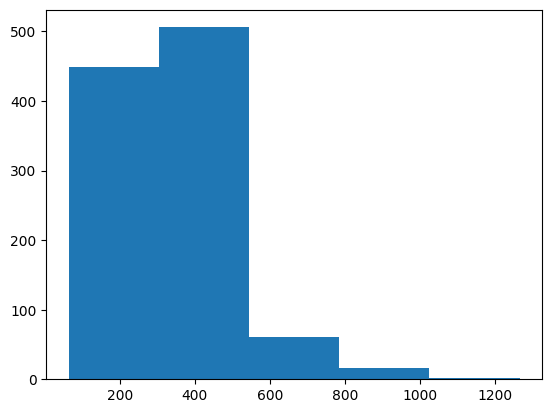

In [32]:
plt.hist(lens,5)

In [33]:
import random

print(tunes_numeric[0])
random.seed(42)
random.shuffle(tunes_numeric)
print(tunes_numeric[0])

[32, 9, 10, 14, 22, 14, 23, 59, 10, 3, 22, 14, 23, 56, 10, 31, 23, 26, 10, 54, 26, 46, 31, 46, 44, 37, 41, 44, 44, 26, 46, 54, 46, 19, 44, 41, 46, 31, 46, 54, 1, 22, 37, 60, 22, 37, 26, 46, 17, 46, 17, 17, 41, 46, 0, 2, 46, 47, 17, 26, 41, 55, 3, 46, 54, 46, 54, 47, 22, 37, 19, 22, 37, 41, 46, 31, 46, 44, 10, 26, 41, 55, 37, 46, 54, 46, 54, 47, 22, 37, 19, 22, 37, 41, 46, 31, 46, 44, 37, 26, 26, 23, 46, 31, 46, 12, 12, 41, 46, 54, 46, 36, 36, 26, 46, 47, 2, 46, 47, 47, 41, 46, 60, 2, 46, 54, 1, 22, 37, 60, 22, 37, 26, 46, 17, 46, 17, 17, 41, 46, 0, 2, 46, 47, 17, 26, 46, 54, 46, 54, 47, 22, 37, 19, 22, 37, 41, 46, 31, 46, 44, 26, 26, 33]
[32, 9, 10, 38, 22, 8, 23, 56, 10, 54, 23, 46, 54, 46, 61, 37, 61, 41, 19, 11, 47, 19, 26, 36, 37, 36, 41, 54, 1, 26, 46, 60, 2, 46, 54, 47, 19, 41, 46, 47, 2, 46, 47, 37, 47, 26, 46, 0, 34, 46, 47, 19, 44, 41, 46, 54, 46, 19, 47, 54, 26, 23, 46, 54, 46, 61, 37, 61, 41, 19, 11, 47, 19, 26, 36, 37, 36, 41, 54, 37, 54, 26, 46, 60, 2, 46, 54, 47, 19, 41, 

In [34]:
t0 = ''
for i in tunes_numeric[0]:
    t0 = t0+itos[i]
print(t0)

`M:6/8
K:G
"G"g2g B^AB|d2d G3|"Em"GAB "Am"A2A|"D7"ABc "G"BAG|
"G"g2g B^AB|d2d G2G|"Em"GAB "Am"A2G|"D7"FGA "G"G3:||:
"D7"A^GA DFA|"G"B^AB G3|"A7"^c=c^c A^ce|"D7"fef def|
"G"g2g de=f|"E7"e2e Bcd|"Am"c2c "D7"Adc| [1"G"B2A G3:|
 [2"G"B2A G2F||"Em"E2E G2G|B2B e2e|"Am"c2A "B7"FBA|"Em"G2F E3|"Em"EFG "Am"ABc|
"B7"B^c^d "Em"e2e|"F#7"f2f f2e|"B7"^def BAF|"Em"E2E G2G|B2B e2e|
"Am"c2A "B7"FBA|"Em"G2F E3|"Em"EFG "Am"ABc|"B7"B^c^d "Em"e2e|
"F#7"f2e "B7"^def |[1"Em"e3 "D7"d3:|[2"Em"e3 "E7"e3||$


In [38]:
seq_joined = [num for tune in tunes_numeric for num in tune]

In [40]:
print(seq_joined[0])
len(seq_joined)

32


363904

In [41]:
with open('seq_joined.pkl','wb') as f:
    pkl.dump(seq_joined,f)

In [3]:
import pickle as pkl